# 1. 🎓 Sistema de Recomendación de Cursos (Clustering)

## Objetivo
Desarrollar un sistema de segmentación de usuarios basado en aprendizaje no supervisado para mejorar la recomendación de cursos en una plataforma educativa online.

## Problema
Las plataformas educativas presentan:
- Gran cantidad de cursos
- Diversidad de perfiles de usuario
- Baja tasa de finalización

## Enfoque
- Análisis exploratorio
- Preprocesamiento
- Clustering (K-Means)
- Interpretación de clusters
- Base para recomendación

2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

3. CARGA DE DATOS

In [2]:
df = pd.read_csv("../data/dataset_recomendador_cursos.csv")

print("Shape:", df.shape)
df.head()

Shape: (50000, 25)


,user_id,age,gender,country,education_level,employment_status,preferred_category,skill_level,learning_goal,courses_viewed,...,avg_session_duration_min,last_activity_days_ago,completion_rate,dropout_rate,revisit_rate,diversity_score,engagement_score,preferred_course_length,preferred_content_type,time_of_day_preference
0,0,56,Other,Chile,Basic,Employed,Marketing,Beginner,Career Change,29,...,16.50,74,0.482759,0.517241,0.87,0.64,0.534873,Long,Mixed,Morning
1,1,41,Female,Spain,Intermediate,Student,Web Dev,Beginner,Upskill,3,...,25.91,20,0.333333,0.666667,0.62,0.65,0.297017,Short,Mixed,Night
2,2,61,Male,Argentina,University,Unemployed,Data Science,Advanced,Hobby,25,...,47.13,61,0.640000,0.360000,0.09,0.66,0.581603,Short,Mixed,Night
3,3,61,Male,Argentina,Master,Unemployed,AI,Advanced,Career Change,3,...,113.35,13,0.000000,1.000000,0.81,0.37,0.377074,Long,Text,Morning
4,4,19,Female,Colombia,Intermediate,Unemployed,AI,Beginner,Hobby,20,...,109.57,35,0.700000,0.300000,0.18,0.78,0.453266,Long,Mixed,Afternoon


4. EDA (Análisis Exploratorio)

4.1 Tipos de datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   50000 non-null  int64  
 1   age                       50000 non-null  int64  
 2   gender                    50000 non-null  str    
 3   country                   50000 non-null  str    
 4   education_level           50000 non-null  str    
 5   employment_status         50000 non-null  str    
 6   preferred_category        50000 non-null  str    
 7   skill_level               50000 non-null  str    
 8   learning_goal             50000 non-null  str    
 9   courses_viewed            50000 non-null  int64  
 10  courses_completed         50000 non-null  int64  
 11  avg_progress              50000 non-null  float64
 12  avg_rating_given          50000 non-null  float64
 13  total_watch_time_hours    50000 non-null  float64
 14  sessions_per_week

4.2 Distribución de variables

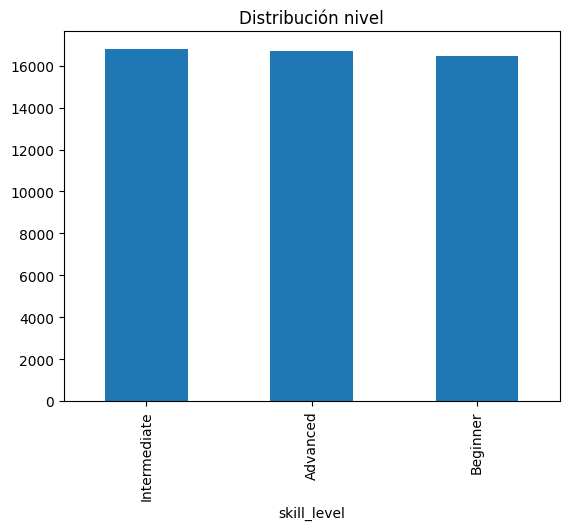

In [4]:
df["skill_level"].value_counts().plot(kind="bar", title="Distribución nivel")
plt.show()

4.3 Engagement

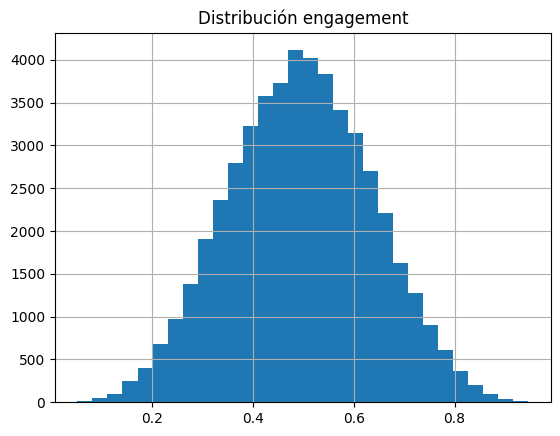

In [5]:
df["engagement_score"].hist(bins=30)
plt.title("Distribución engagement")
plt.show()

4.4 Relación categoría - engagement

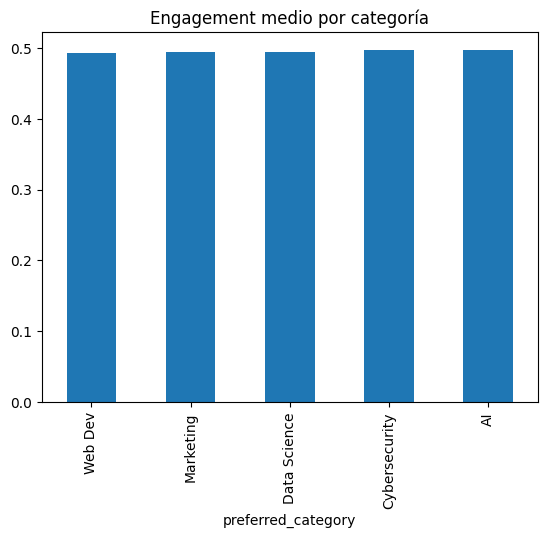

In [6]:
df.groupby("preferred_category")["engagement_score"].mean().sort_values().plot(kind="bar")
plt.title("Engagement medio por categoría")
plt.show()

4.5 Correlaciones

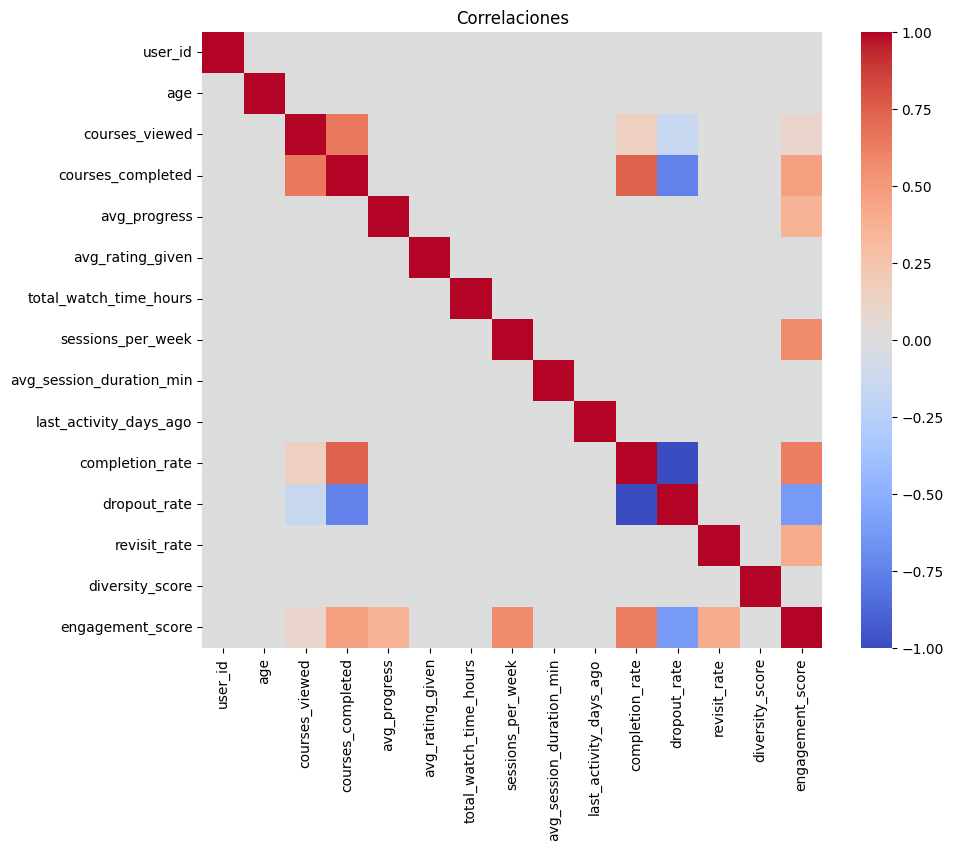

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlaciones")
plt.show()

5. PREPROCESAMIENTO

In [8]:
numeric_features = [
    "age",
    "courses_viewed",
    "courses_completed",
    "avg_progress",
    "avg_rating_given",
    "total_watch_time_hours",
    "sessions_per_week",
    "avg_session_duration_min",
    "last_activity_days_ago",
    "completion_rate",
    "dropout_rate",
    "revisit_rate",
    "diversity_score",
    "engagement_score"
]

categorical_features = [
    "gender",
    "country",
    "education_level",
    "employment_status",
    "preferred_category",
    "skill_level",
    "learning_goal",
    "preferred_course_length",
    "preferred_content_type",
    "time_of_day_preference"
]

X = df[numeric_features + categorical_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_processed = preprocessor.fit_transform(X)

print("Shape transformado:", X_processed.shape)

Shape transformado: (50000, 49)


6. ELECCIÓN DE CLUSTERS

In [ ]:
inertias = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_processed)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels))

6.1 Método del codo

In [ ]:
plt.plot(k_range, inertias, marker='o')
plt.title("Método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

6.2 Silhouette

In [ ]:
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette score")
plt.show()

7. CLUSTERING FINAL

In [ ]:
best_k = k_range[np.argmax(sil_scores)]
print("Mejor k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_processed)

8. VISUALIZACIÓN CON PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed.toarray())

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="tab10")
plt.title("Clusters")
plt.show()

9. PERFILADO DE CLUSTERS

9.1 Variables categóricas

In [ ]:
cat_profile = {}

for col in categorical_features:
    cat_profile[col] = df.groupby("cluster")[col].agg(lambda x: x.mode()[0])

cat_profile = pd.DataFrame(cat_profile)

cluster_profile = pd.concat([profile, cat_profile], axis=1)

cluster_profile

10. INTERPRETACIÓN

## Interpretación de clusters

Ejemplo:

### Cluster 0
- Alto engagement
- Alta finalización
→ Usuarios comprometidos

### Cluster 1
- Baja actividad
- Alto abandono
→ Riesgo de abandono

### Cluster 2
- Alta diversidad
→ Exploradores

### Cluster 3
- Nivel avanzado
→ Usuarios expertos

11. CONEXIÓN CON RECOMENDADOR

In [ ]:
courses = pd.read_csv("../data/courses_catalog.csv")

def simple_recommend(user):
    return courses[
        (courses["category"] == user["preferred_category"]) &
        (courses["difficulty_level"] == user["skill_level"])
    ].sort_values("rating_avg", ascending=False).head(5)

# ejemplo
user = df.iloc[0]
simple_recommend(user)

12. CONCLUSIONES (Markdown)